Packages

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
%matplotlib inline
import nltk 
# !pip install seaborn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
import seaborn as sns
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
# from gensim.models import Word2Vec, KeyedVectors

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Load datasets

In [2]:
path = 'spam.csv'
df = pd.read_csv(path,sep=',', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


suppression des colonnes sauf v1(represente les classes spam et non spam), v2 est le message recu. Ces colonnes n'apportent aucune inforamtion sur la tache que nous voulons effectuer

In [4]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


Renommer les variables v1 en label et v2 en text

In [6]:
df.rename(columns={'v1':'label','v2':'text'},inplace=True)

Convertion de la variable label

In [7]:
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Verifiaction valeurs manquantes

In [8]:
df.isnull().sum()

label    0
text     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(403)

403 lignes sont dupliques. Supprimons les lignes dupliquees

In [10]:
df = df.drop_duplicates(keep='first')
df.shape

(5169, 2)

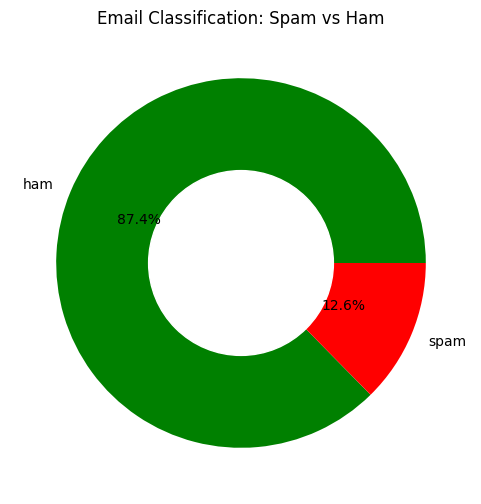

In [13]:
plt.figure(figsize=(6,6))
# icon email dans le titre

plt.title('Email Classification: Spam vs Ham')
my_circle = plt.Circle( (0,0), 0.5, color='white')
plt.pie(df['label'].value_counts(), labels=['ham','spam'], colors=['green','red'],autopct='%1.1f%%')
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

Dependance entre Longueur du text et label

In [14]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [15]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


Distribution des caracteres par rapport au message spam et nom spam

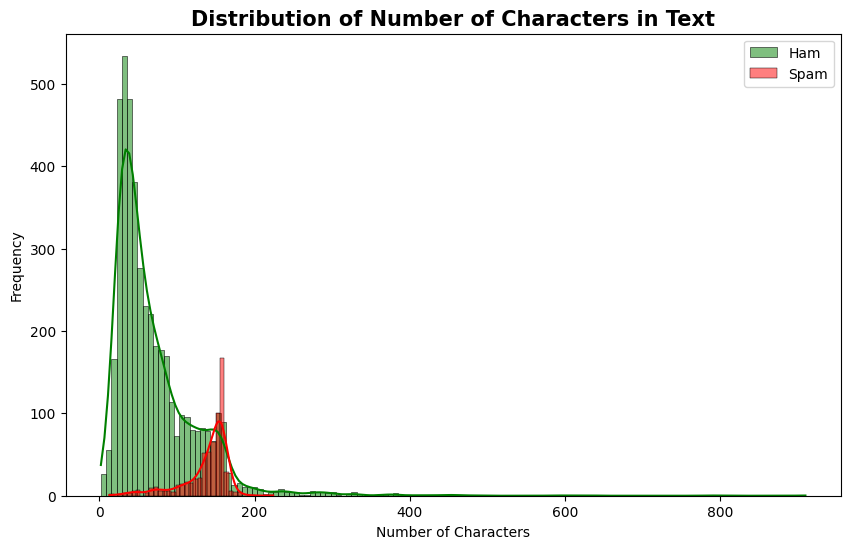

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(df[df['label']==0]['num_characters'],color='green',kde=True,label='Ham')
sns.histplot(df[df['label']==1]['num_characters'],color='red',kde=True,label='Spam')

plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Characters in Text',fontdict={'fontsize':15,'fontweight':'bold'})
plt.legend()
plt.show()

Distribution du nombre de mots dans le message par rapport sa classe(spam , ham)

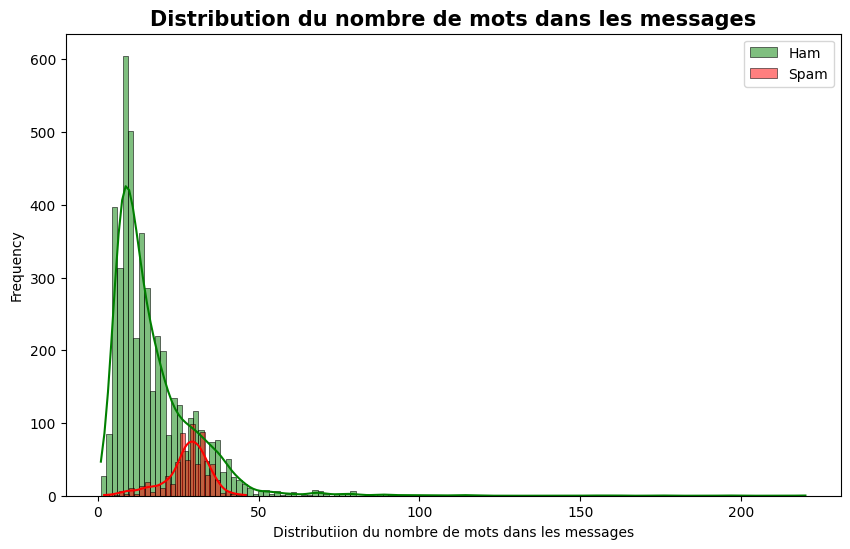

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(df[df['label']==0]['num_words'],color='green',kde=True,label='Ham')
sns.histplot(df[df['label']==1]['num_words'],color='red',kde=True,label='Spam')

plt.xlabel('Distributiion du nombre de mots dans les messages')
plt.ylabel('Frequency')
plt.title('Distribution du nombre de mots dans les messages',fontdict={'fontsize':15,'fontweight':'bold'})
plt.legend()
plt.show()

Correlation

In [18]:
df[['label','num_characters','num_words','num_sentences']].corr()

,label,num_characters,num_words,num_sentences
label,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

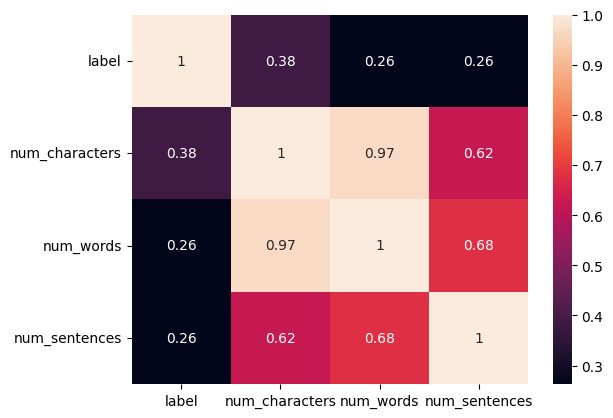

In [19]:
sns.heatmap(df[['label','num_characters','num_words','num_sentences']].corr(),annot=True)

Data Preprocessing

In [20]:
# Stemming
ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        if i not in set(stopwords.words('english')):
            y.append(i)

    return ' '.join(y)


Preprocessing text 

In [21]:
df['transformed_text'] = df['text'].apply(transform_text)

In [22]:
df.head()

,label,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goes usf lives around though


Word Cloud Spam

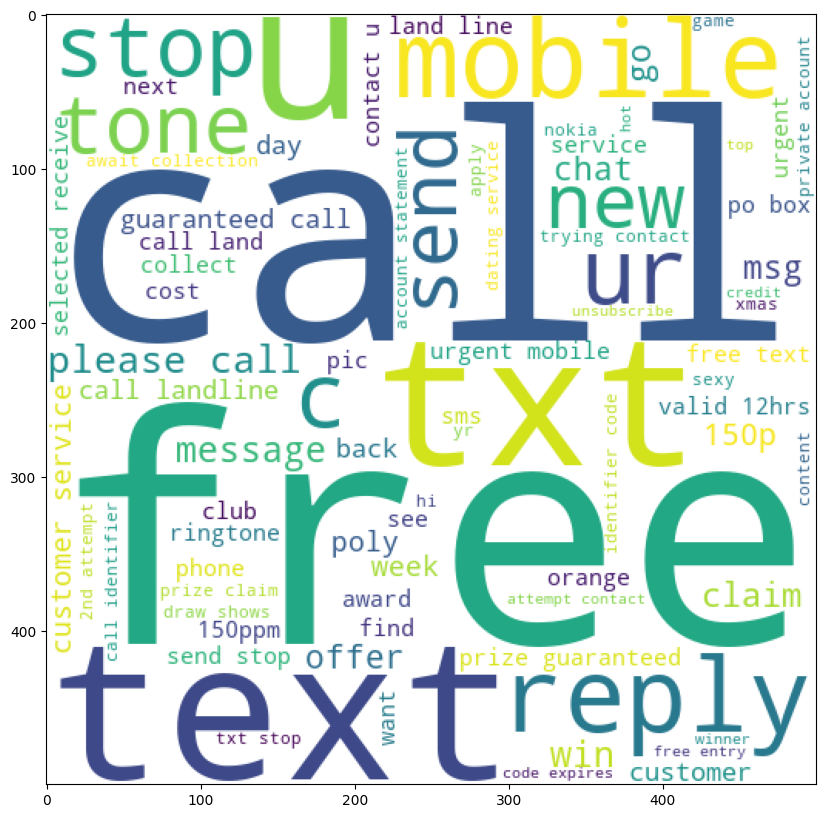

In [23]:
from wordcloud import WordCloud

wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')
spam_wc = wc.generate(df[df['label'] == 1]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (18,10))
plt.imshow(spam_wc)
plt.show()

Word cloud pour la ham

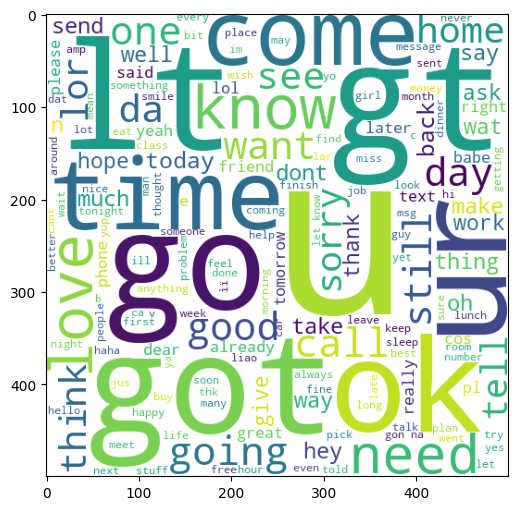

In [24]:
ham_wc = wc.generate(df[df['label'] == 0]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(ham_wc)
plt.show()

Vectorisation
1. Evaluation des modeles en fonction des techniques de vectorisation:
    1. TF-IDF
    2. N-Gram
    3. Bag of Words
    4. Word2Vect(CBOW, SkipGram)
    5. Glove

In [25]:
# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
tfidf = TfidfVectorizer(max_features=3000)
n_grams = CountVectorizer(ngram_range=(2,2))
bagofwords = CountVectorizer()
# Word2Vec
# cbow = Word2Vec(df['transformed_text'].apply(lambda x: x.split()),min_count=1,window=5,sg=0)
from sklearn.svm import SVC
svc = SVC(kernel= "sigmoid", gamma  = 1.0)


In [26]:
vectorizers = {'tfidf':tfidf,'n_grams':n_grams,'bagofwords':bagofwords}

from sklearn.model_selection import train_test_split



def classifer(X_train, y_train):
    svc = SVC(kernel= "sigmoid", gamma  = 1.0)
    svc.fit(X_train,y_train)
    return svc
    



{'i': 0, 'vectorizer': 'tfidf'}
{'i': 1, 'vectorizer': 'n_grams'}
{'i': 2, 'vectorizer': 'bagofwords'}


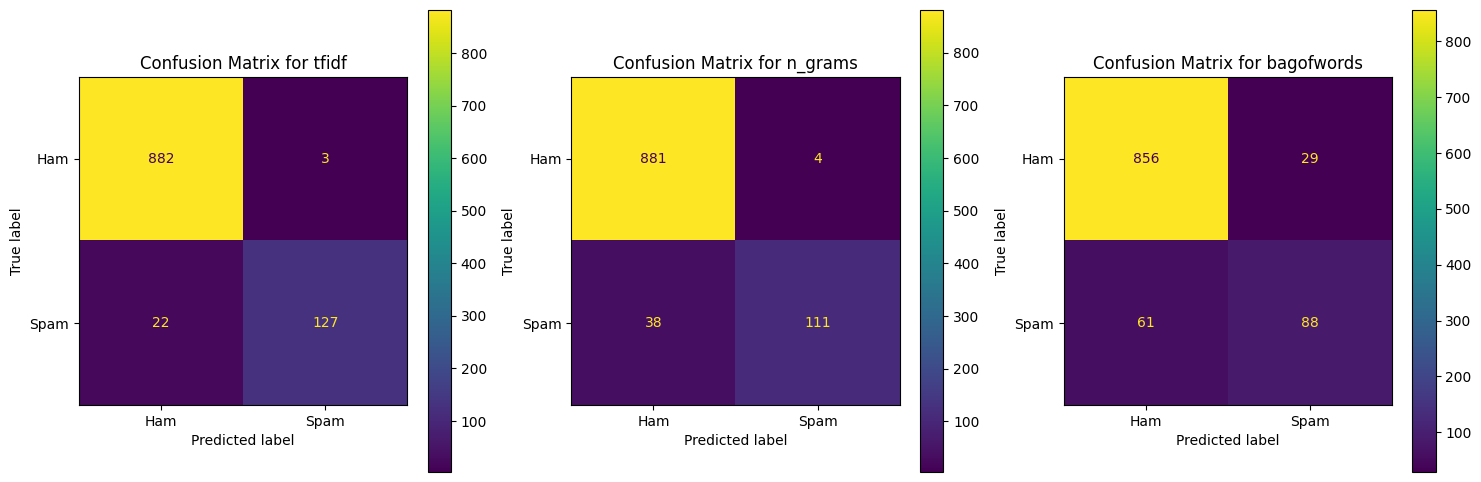

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(1, len(vectorizers), figsize=(18,6))
for i, vectorizer in enumerate(vectorizers):
    print({"i":i,"vectorizer":vectorizer})
    X = vectorizers[vectorizer].fit_transform(df['transformed_text']).toarray()
    y = df['label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    svc = classifer(X_train, y_train)
    y_pred = svc.predict(X_test)

    ax[i].set_title(f'Confusion Matrix for {vectorizer}')
    cm = confusion_matrix(y_test, y_pred)
    cmd = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
    cmd.plot(ax=ax[i])
plt.show()